# 4. Final Model Comparison

**Objective:** Compare all approaches on the same test set.

Models compared:
1. **Autoencoder (best variant)** — our main unsupervised model
2. **Supervised DNN** — internal deep learning comparison
3. **Logistic Regression** — simple linear baseline
4. **Random Forest** — classic ML baseline
5. **XGBoost** — tabular SOTA
6. **LightGBM** — tabular SOTA

Satisfies rubric expectation #3: "Give a quick comparison of your model
performance against some state-of-the-art ones. You are not expected to
beat the state-of-the-art models!"

## 4.1 Setup

In [9]:
%matplotlib inline

import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

from src.preprocessing import load_processed
from src.autoencoder import build_autoencoder
from src.model import FraudDetectorDNN
from src.evaluate import (compute_reconstruction_errors, evaluate,
                          find_threshold_by_percentile, find_optimal_threshold,
                          get_predictions)
from src.baselines import run_all_baselines
from src.utils import get_device, set_seed, load_checkpoint
from src.dataset import FraudDataset

set_seed(42)
device = get_device()
data = load_processed("../data/processed", "../models")
print(f"Test set: {data['x_test'].shape}, fraud rate: {data['y_test'].mean():.2%}")

/Users/ongviviana/miniconda3/envs/DeepL/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Test set: (246787, 16), fraud rate: 14.96%


## 4.2 Load Best Autoencoder

Load the best variant from Notebook 2. If you identified a different winner,
update the checkpoint path and hidden_dims below.

In [10]:
# Load the best autoencoder (update path if a different variant won)
ae_checkpoint = load_checkpoint("../models/autoencoder_best.pt", device)
ae_meta = ae_checkpoint["metadata"]
print(f"Autoencoder config: {ae_meta}")

ae_model = build_autoencoder(
    model_type=ae_meta["model_type"],
    input_dim=ae_meta["input_dim"],
    hidden_dims=ae_meta["hidden_dims"],
    dropout=ae_meta["dropout"],
).to(device)
ae_model.load_state_dict(ae_checkpoint["model_state_dict"])
ae_model.eval()

# Evaluate on test set
test_ds = FraudDataset(data["x_test"], data["y_test"])
test_loader = DataLoader(test_ds, batch_size=1024)

ae_errors, ae_labels = compute_reconstruction_errors(ae_model, test_loader, device)
ae_threshold = float(ae_meta["threshold_unsupervised"])
print(f"\nAutoencoder threshold: {ae_threshold:.6f}")
ae_metrics = evaluate(ae_errors, ae_labels, ae_threshold, label="Autoencoder")

Autoencoder config: {'model_type': 'vanilla', 'input_dim': 16, 'hidden_dims': [64, 32, 16], 'dropout': 0.2, 'noise_std': 0.1, 'threshold_unsupervised': np.float32(0.2564126), 'threshold_f1_optimal': 0.13919048011302948, 'threshold_percentile': 95.0, 'feature_names': ['Transaction Amount', 'Quantity', 'Customer Age', 'Account Age Days', 'Address Match', 'Hour_Sin', 'Hour_Cos', 'Payment Method_bank transfer', 'Payment Method_credit card', 'Payment Method_debit card', 'Product Category_electronics', 'Product Category_health & beauty', 'Product Category_home & garden', 'Product Category_toys & games', 'Device Used_mobile', 'Device Used_tablet'], 'best_epoch': 31, 'best_val_loss': 0.11199903359033345}

Autoencoder threshold: 0.256413

  Autoencoder Set Evaluation   (threshold = 0.256413)
              precision    recall  f1-score   support

      Normal     0.8681    0.9506    0.9075    209868
       Fraud     0.3892    0.1791    0.2453     36919

    accuracy                         0.835

## 4.3 Load Supervised DNN

Trained in Notebook 3.

In [11]:
# Load supervised DNN
try:
    dnn_checkpoint = load_checkpoint("../models/supervised_best.pt", device)
    dnn_meta = dnn_checkpoint["metadata"]
    dnn_model = FraudDetectorDNN(
        input_dim=dnn_meta["input_dim"],
        hidden_dims=dnn_meta["hidden_dims"],
        dropout=dnn_meta["dropout"],
    ).to(device)
    dnn_model.load_state_dict(dnn_checkpoint["model_state_dict"])
    dnn_model.eval()
    
    dnn_probs, dnn_labels = get_predictions(dnn_model, test_loader, device)
    dnn_threshold = float(dnn_meta["threshold"])
    dnn_metrics = evaluate(dnn_probs, dnn_labels, dnn_threshold, label="Supervised DNN")
except FileNotFoundError:
    print("supervised_best.pt not found. Run Notebook 3 first.")
    dnn_metrics = None


  Supervised DNN Set Evaluation   (threshold = 0.642298)
              precision    recall  f1-score   support

      Normal     0.9199    0.9043    0.9121    209868
       Fraud     0.5040    0.5524    0.5271     36919

    accuracy                         0.8517    246787
   macro avg     0.7119    0.7284    0.7196    246787
weighted avg     0.8577    0.8517    0.8545    246787

Confusion Matrix:
                Pred Normal   Pred Fraud
  True Normal        189794        20074
  True Fraud          16525        20394

  ROC-AUC:  0.8125
  PR-AUC:   0.5689  (better metric for imbalanced data)
  F1:       0.5271


## 4.4 Run SOTA Baselines

Logistic Regression, Random Forest, XGBoost, and LightGBM.
These are genuinely state-of-the-art for tabular fraud detection.

In [12]:
# Build supervised training data (same logic as Notebook 3)
rng = np.random.default_rng(42)
perm = rng.permutation(len(data["y_val"]))
half = len(perm) // 2

x_train_sup = np.concatenate([data["x_train"], data["x_val"][perm[:half]]])
y_train_sup = np.concatenate([
    np.zeros(len(data["x_train"]), dtype=np.int64),
    data["y_val"][perm[:half]],
])

baseline_results = run_all_baselines(
    x_train_sup, y_train_sup,
    data["x_test"], data["y_test"],
)

  Running baseline comparison
  Train size: 1102772  (fraud rate: 0.0168)
  Test size:  246787   (fraud rate: 0.1496)
  scale_pos_weight: 58.58

  Training LogisticRegression...
    Train time: 0.8s  |  PR-AUC: 0.4941  |  F1: 0.4116

  Training RandomForest...
    Train time: 89.6s  |  PR-AUC: 0.4883  |  F1: 0.1692

  Training XGBoost...
    Train time: 13.5s  |  PR-AUC: 0.5679  |  F1: 0.4891

  Training LightGBM...


/Users/ongviviana/miniconda3/envs/DeepL/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


    Train time: 11.6s  |  PR-AUC: 0.5724  |  F1: 0.4878


## 4.5 Final Comparison Table

In [13]:
# Assemble all results into one table
all_results = []

# Autoencoder
all_results.append({
    "Model": "Autoencoder (ours)",
    "Type": "Unsupervised",
    "Precision": ae_metrics["precision"],
    "Recall": ae_metrics["recall"],
    "F1": ae_metrics["f1"],
    "PR-AUC": ae_metrics["pr_auc"],
    "ROC-AUC": ae_metrics["roc_auc"],
})

# Supervised DNN
if dnn_metrics:
    all_results.append({
        "Model": "Supervised DNN",
        "Type": "Supervised (DL)",
        "Precision": dnn_metrics["precision"],
        "Recall": dnn_metrics["recall"],
        "F1": dnn_metrics["f1"],
        "PR-AUC": dnn_metrics["pr_auc"],
        "ROC-AUC": dnn_metrics["roc_auc"],
    })

# Baselines
for r in baseline_results:
    all_results.append({
        "Model": r["model"],
        "Type": "Supervised (ML)",
        "Precision": r["precision"],
        "Recall": r["recall"],
        "F1": r["f1"],
        "PR-AUC": r["pr_auc"],
        "ROC-AUC": r["roc_auc"],
    })

comparison_df = pd.DataFrame(all_results).sort_values("PR-AUC", ascending=False)
comparison_df

,Model,Type,Precision,Recall,F1,PR-AUC,ROC-AUC
5,LightGBM,Supervised (ML),0.381400,0.676800,0.487800,0.572400,0.813700
1,Supervised DNN,Supervised (DL),0.503954,0.552398,0.527065,0.568908,0.812472
4,XGBoost,Supervised (ML),0.385600,0.668500,0.489100,0.567900,0.811000
2,LogisticRegression,Supervised (ML),0.298500,0.662400,0.411600,0.494100,0.766900
3,RandomForest,Supervised (ML),0.977100,0.092600,0.169200,0.488300,0.755100
0,Autoencoder (ours),Unsupervised,0.389226,0.179068,0.245288,0.297273,0.618741


## 4.6 Comparison Plots

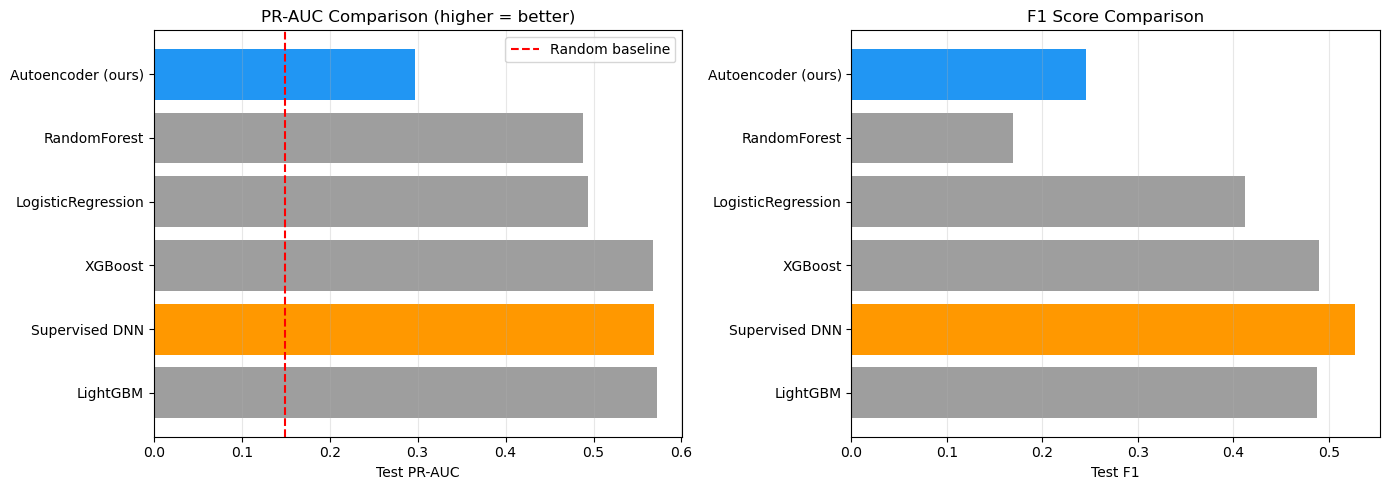

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PR-AUC bar chart
models = comparison_df["Model"].tolist()
pr_aucs = comparison_df["PR-AUC"].tolist()
colors = ["#2196F3" if "Autoencoder" in m else "#FF9800" if "DNN" in m else "#9E9E9E" for m in models]
axes[0].barh(models, pr_aucs, color=colors)
axes[0].axvline(x=data["y_test"].mean(), linestyle="--", color="red", label="Random baseline")
axes[0].set_xlabel("Test PR-AUC")
axes[0].set_title("PR-AUC Comparison (higher = better)")
axes[0].legend()
axes[0].grid(alpha=0.3, axis="x")

# F1 bar chart
f1s = comparison_df["F1"].tolist()
axes[1].barh(models, f1s, color=colors)
axes[1].set_xlabel("Test F1")
axes[1].set_title("F1 Score Comparison")
axes[1].grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig("../figures/fig09_all_models_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
# Save comparison table to CSV for the report
comparison_df.to_csv("../experiments/final_comparison.csv", index=False)
print("Saved to experiments/final_comparison.csv")

Saved to experiments/final_comparison.csv


## 4.7 Discussion

**Expected findings:**

XGBoost and LightGBM will likely outperform both deep learning models on
this tabular dataset. This is well-documented in the literature — gradient-
boosted trees are consistently SOTA on structured/tabular data.

However, the autoencoder has a unique advantage: **it requires no fraud labels
during training**. In practice, fraud patterns evolve faster than labeled
datasets can be curated. An unsupervised detector that can flag novel fraud
patterns without retraining on labeled examples has significant operational value.

**Tradeoff to discuss in the report:**

| | Supervised (XGBoost/DNN) | Unsupervised (Autoencoder) |
|---|---|---|
| Performance | Higher | Lower |
| Requires fraud labels? | Yes | No |
| Detects novel fraud? | Only if similar to training fraud | Yes (any deviation from normal) |
| Retraining cost | Need new labeled data | Just new normal data |

**Figures generated:**
- `fig09_all_models_comparison.png`